# **Features engineering**

In [54]:
# Import libraries
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [37]:
# Loading the data
input_path = Path("..") / 'data' / 'interim' / 'dataset_merged.csv'
df = pd.read_csv(input_path)
display(df.head(5))
print("Shape of the piezometer dataframe:\n", df.shape)

,date_index,latitude,longitude,sunrise,sunset,daylight_duration,precipitation_sum,shortwave_radiation_sum,et0_fao_evapotranspiration,cloud_cover_mean,pressure_msl_mean,wind_speed_10m_mean,soil_moisture_0_to_100cm_mean,soil_temperature_0_to_100cm_mean,code_bss,bss_id,niveau_nappe_eau,mode_obtention,nom_producteur
0,2017-01-01,42.685696,2.685378,2017-01-01T07:19,2017-01-01T16:26,32800.70,0.0,7.88,0.95,47,1024.5,5.3,0.244,9.2,10906X0039/C2-1,BSS002MNYD,101.85,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...
1,2017-01-02,42.685696,2.685378,2017-01-02T07:19,2017-01-02T16:27,32850.58,0.0,4.29,0.56,93,1022.0,4.6,0.244,9.2,10906X0039/C2-1,BSS002MNYD,101.89,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...
2,2017-01-03,42.685696,2.685378,2017-01-03T07:19,2017-01-03T16:28,32904.28,0.0,8.02,1.59,3,1023.5,11.8,0.244,8.9,10906X0039/C2-1,BSS002MNYD,101.98,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...
3,2017-01-04,42.685696,2.685378,2017-01-04T07:19,2017-01-04T16:29,32961.75,0.0,8.08,2.52,5,1022.9,25.2,0.244,8.8,10906X0039/C2-1,BSS002MNYD,101.98,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...
4,2017-01-05,42.685696,2.685378,2017-01-05T07:19,2017-01-05T16:30,33022.91,0.0,6.93,2.07,14,1026.5,30.5,0.243,8.7,10906X0039/C2-1,BSS002MNYD,102.01,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...


Shape of the piezometer dataframe:
 (3405, 19)


In [38]:
df.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['date_index', 'latitude', 'longitude', 'sunrise', 'sunset',
       'daylight_duration', 'precipitation_sum', 'shortwave_radiation_sum',
       'et0_fao_evapotranspiration', 'cloud_cover_mean', 'pressure_msl_mean',
       'wind_speed_10m_mean', 'soil_moisture_0_to_100cm_mean',
       'soil_temperature_0_to_100cm_mean', 'code_bss', 'bss_id',
       'niveau_nappe_eau', 'mode_obtention', 'nom_producteur'],
      dtype='str')>

In [39]:
# Index define as date_index
df["date_index"] = pd.to_datetime(df["date_index"])
df = df.set_index("date_index")
display(df.head(5))

,latitude,longitude,sunrise,sunset,daylight_duration,precipitation_sum,shortwave_radiation_sum,et0_fao_evapotranspiration,cloud_cover_mean,pressure_msl_mean,wind_speed_10m_mean,soil_moisture_0_to_100cm_mean,soil_temperature_0_to_100cm_mean,code_bss,bss_id,niveau_nappe_eau,mode_obtention,nom_producteur
date_index,,,,,,,,,,,,,,,,,,
2017-01-01,42.685696,2.685378,2017-01-01T07:19,2017-01-01T16:26,32800.70,0.0,7.88,0.95,47,1024.5,5.3,0.244,9.2,10906X0039/C2-1,BSS002MNYD,101.85,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...
2017-01-02,42.685696,2.685378,2017-01-02T07:19,2017-01-02T16:27,32850.58,0.0,4.29,0.56,93,1022.0,4.6,0.244,9.2,10906X0039/C2-1,BSS002MNYD,101.89,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...
2017-01-03,42.685696,2.685378,2017-01-03T07:19,2017-01-03T16:28,32904.28,0.0,8.02,1.59,3,1023.5,11.8,0.244,8.9,10906X0039/C2-1,BSS002MNYD,101.98,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...
2017-01-04,42.685696,2.685378,2017-01-04T07:19,2017-01-04T16:29,32961.75,0.0,8.08,2.52,5,1022.9,25.2,0.244,8.8,10906X0039/C2-1,BSS002MNYD,101.98,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...
2017-01-05,42.685696,2.685378,2017-01-05T07:19,2017-01-05T16:30,33022.91,0.0,6.93,2.07,14,1026.5,30.5,0.243,8.7,10906X0039/C2-1,BSS002MNYD,102.01,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...


In [40]:
df.isna().sum()

latitude                            0
longitude                           0
sunrise                             0
sunset                              0
daylight_duration                   0
precipitation_sum                   0
shortwave_radiation_sum             0
et0_fao_evapotranspiration          0
cloud_cover_mean                    0
pressure_msl_mean                   0
wind_speed_10m_mean                 0
soil_moisture_0_to_100cm_mean       0
soil_temperature_0_to_100cm_mean    0
code_bss                            0
bss_id                              0
niveau_nappe_eau                    0
mode_obtention                      0
nom_producteur                      0
dtype: int64

In [41]:
# Shows duplicated rows for a date
print("Duplicated dates: ", df.index.duplicated().sum())
df[df.index.duplicated(keep=False)].sort_index()

# Keep only one reading per day
df = df[~df.index.duplicated(keep="first")]

# Check for actual date gaps
inferred = pd.infer_freq(df.index)
print("Detected frequency: ", inferred)  # should print 'D' if perfectly daily and gap-free
full_range = pd.date_range(df.index.min(), df.index.max(), freq="D")
missing_dates = full_range.difference(df.index)
print("Missing dates: ",len(missing_dates))
print(missing_dates[:37])

Duplicated dates:  3
Detected frequency:  None
Missing dates:  79
DatetimeIndex(['2019-09-20', '2023-02-06', '2023-02-07', '2023-02-08',
               '2023-02-09', '2023-02-10', '2023-02-11', '2023-02-12',
               '2023-02-13', '2023-02-14', '2023-02-15', '2023-02-16',
               '2023-02-17', '2023-02-18', '2023-02-19', '2023-02-20',
               '2023-02-21', '2023-02-22', '2024-05-12', '2024-05-13',
               '2024-05-14', '2024-05-15', '2024-05-16', '2024-05-17',
               '2024-05-18', '2024-05-19', '2024-05-20', '2024-05-21',
               '2024-05-22', '2024-09-10', '2024-09-11', '2024-09-12',
               '2024-09-13', '2024-09-14', '2024-09-15', '2024-09-16',
               '2024-09-17'],
              dtype='datetime64[us]', freq=None)


In [42]:
df.loc['2023-02-05']

latitude                                                                    42.685696
longitude                                                                    2.685378
sunrise                                                              2023-02-05T06:59
sunset                                                               2023-02-05T17:07
daylight_duration                                                             36463.4
precipitation_sum                                                                 0.0
shortwave_radiation_sum                                                         11.39
et0_fao_evapotranspiration                                                       2.97
cloud_cover_mean                                                                   31
pressure_msl_mean                                                              1032.6
wind_speed_10m_mean                                                              30.3
soil_moisture_0_to_100cm_mean                         

In [43]:
# Confirm series.index.freq prints 'D' 
series = df["niveau_nappe_eau"].sort_index().asfreq("D").interpolate()

print("Detected frequency: ",series.index.freq)     # should now print 'D'
print("Na dates: ", series.isna().sum())   # should be 0
missing_dates = full_range.difference(series.index)
print("Missing dates: ",len(missing_dates))
print(missing_dates[:10])

Detected frequency:  <Day>
Na dates:  0
Missing dates:  0
DatetimeIndex([], dtype='datetime64[us]', freq='D')


# Feature engineering

In [44]:
df.columns.tolist()

['latitude',
 'longitude',
 'sunrise',
 'sunset',
 'daylight_duration',
 'precipitation_sum',
 'shortwave_radiation_sum',
 'et0_fao_evapotranspiration',
 'cloud_cover_mean',
 'pressure_msl_mean',
 'wind_speed_10m_mean',
 'soil_moisture_0_to_100cm_mean',
 'soil_temperature_0_to_100cm_mean',
 'code_bss',
 'bss_id',
 'niveau_nappe_eau',
 'mode_obtention',
 'nom_producteur']

In [45]:
# Computation of the cumulative precipitation during the 7-30-90 last days
def cumulative_precipitation(df, days: int) -> pd.DataFrame:
    """
    Computation of the cumulative precipitation during the last 7-30-90 days
    """
    df[f'P_cum_{days}d'] = df['precipitation_sum'].rolling(window=days).sum()
    return df

def cumulative_eff_precipitation(df, days: int) -> pd.DataFrame:
    """
    Computation of the cumulative precipitation during the last 30-90 days minus 
    the et0_fao_evapotranspiration (mining the evaporation)
    """
    df[f'Peff_cum_{days}d'] = (df['precipitation_sum'] - df['et0_fao_evapotranspiration']).rolling(window=days).sum()
    return df

def mean_temp(df, days: int) -> pd.DataFrame:
    """
    Computation of the temperature mean on the last x days
    """
    df[f'Temperature_mean_{days}d'] = round(df['soil_temperature_0_to_100cm_mean'].rolling(window=days).mean(), 2)
    return df

In [46]:
cumulative_precipitation(df, days = 30)
cumulative_precipitation(df, days = 90)
cumulative_eff_precipitation(df, days = 30)
cumulative_eff_precipitation(df, days = 90)
mean_temp(df, days = 30)
mean_temp(df, days = 90)
display(df.head(10))
print("Shape of the df:", df.shape)

,latitude,longitude,sunrise,sunset,daylight_duration,precipitation_sum,shortwave_radiation_sum,et0_fao_evapotranspiration,cloud_cover_mean,pressure_msl_mean,...,bss_id,niveau_nappe_eau,mode_obtention,nom_producteur,P_cum_30d,P_cum_90d,Peff_cum_30d,Peff_cum_90d,Temperature_mean_30d,Temperature_mean_90d
date_index,,,,,,,,,,,,,,,,,,,,,
2017-01-01,42.685696,2.685378,2017-01-01T07:19,2017-01-01T16:26,32800.70,0.0,7.88,0.95,47,1024.5,...,BSS002MNYD,101.85,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-02,42.685696,2.685378,2017-01-02T07:19,2017-01-02T16:27,32850.58,0.0,4.29,0.56,93,1022.0,...,BSS002MNYD,101.89,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-03,42.685696,2.685378,2017-01-03T07:19,2017-01-03T16:28,32904.28,0.0,8.02,1.59,3,1023.5,...,BSS002MNYD,101.98,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-04,42.685696,2.685378,2017-01-04T07:19,2017-01-04T16:29,32961.75,0.0,8.08,2.52,5,1022.9,...,BSS002MNYD,101.98,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-05,42.685696,2.685378,2017-01-05T07:19,2017-01-05T16:30,33022.91,0.0,6.93,2.07,14,1026.5,...,BSS002MNYD,102.01,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-06,42.685696,2.685378,2017-01-06T07:19,2017-01-06T16:31,33087.68,0.0,8.43,1.94,1,1029.7,...,BSS002MNYD,102.05,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-07,42.685696,2.685378,2017-01-07T07:19,2017-01-07T16:32,33155.99,0.0,8.31,2.44,7,1029.8,...,BSS002MNYD,102.12,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-08,42.685696,2.685378,2017-01-08T07:19,2017-01-08T16:33,33227.75,0.0,5.26,2.68,60,1027.5,...,BSS002MNYD,102.14,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-09,42.685696,2.685378,2017-01-09T07:19,2017-01-09T16:34,33303.06,0.0,8.32,2.08,27,1025.4,...,BSS002MNYD,102.15,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,NaN,NaN,NaN,NaN,NaN,NaN


Shape of the df: (3402, 24)


In [47]:
df["P_cum_30d"]             = df["P_cum_30d"].fillna(df["P_cum_30d"].dropna().iloc[0])
df["P_cum_90d"]             = df["P_cum_90d"].fillna(df["P_cum_90d"].dropna().iloc[0])
df["Peff_cum_30d"]           = df["Peff_cum_30d"].fillna(df["Peff_cum_30d"].dropna().iloc[0])
df["Peff_cum_90d"]          = df["Peff_cum_90d"].fillna(df["Peff_cum_90d"].dropna().iloc[0])
df["Temperature_mean_30d"]  = df["Temperature_mean_30d"].fillna(df["Temperature_mean_30d"].dropna().iloc[0])
df["Temperature_mean_90d"]  = df["Temperature_mean_90d"].fillna(df["Temperature_mean_90d"].dropna().iloc[0])

In [48]:
df.isnull().sum()

latitude                            0
longitude                           0
sunrise                             0
sunset                              0
daylight_duration                   0
precipitation_sum                   0
shortwave_radiation_sum             0
et0_fao_evapotranspiration          0
cloud_cover_mean                    0
pressure_msl_mean                   0
wind_speed_10m_mean                 0
soil_moisture_0_to_100cm_mean       0
soil_temperature_0_to_100cm_mean    0
code_bss                            0
bss_id                              0
niveau_nappe_eau                    0
mode_obtention                      0
nom_producteur                      0
P_cum_30d                           0
P_cum_90d                           0
Peff_cum_30d                        0
Peff_cum_90d                        0
Temperature_mean_30d                0
Temperature_mean_90d                0
dtype: int64

In [49]:
df.columns.tolist()

['latitude',
 'longitude',
 'sunrise',
 'sunset',
 'daylight_duration',
 'precipitation_sum',
 'shortwave_radiation_sum',
 'et0_fao_evapotranspiration',
 'cloud_cover_mean',
 'pressure_msl_mean',
 'wind_speed_10m_mean',
 'soil_moisture_0_to_100cm_mean',
 'soil_temperature_0_to_100cm_mean',
 'code_bss',
 'bss_id',
 'niveau_nappe_eau',
 'mode_obtention',
 'nom_producteur',
 'P_cum_30d',
 'P_cum_90d',
 'Peff_cum_30d',
 'Peff_cum_90d',
 'Temperature_mean_30d',
 'Temperature_mean_90d']

In [50]:
output_path = Path('..') / 'data' / 'interim' / 'featured_data_TO_DELETE.csv'

df.to_csv(output_path)

In [51]:
# Loading the data
input_path = Path("..") / 'data' / 'interim' / 'featured_data_TO_DELETE.csv'
df = pd.read_csv(input_path)
display(df.head(5))
print("Shape of the piezometer dataframe:\n", df.shape)

,date_index,latitude,longitude,sunrise,sunset,daylight_duration,precipitation_sum,shortwave_radiation_sum,et0_fao_evapotranspiration,cloud_cover_mean,...,bss_id,niveau_nappe_eau,mode_obtention,nom_producteur,P_cum_30d,P_cum_90d,Peff_cum_30d,Peff_cum_90d,Temperature_mean_30d,Temperature_mean_90d
0,2017-01-01,42.685696,2.685378,2017-01-01T07:19,2017-01-01T16:26,32800.70,0.0,7.88,0.95,47,...,BSS002MNYD,101.85,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,87.9,275.8,44.1,90.41,8.05,9.87
1,2017-01-02,42.685696,2.685378,2017-01-02T07:19,2017-01-02T16:27,32850.58,0.0,4.29,0.56,93,...,BSS002MNYD,101.89,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,87.9,275.8,44.1,90.41,8.05,9.87
2,2017-01-03,42.685696,2.685378,2017-01-03T07:19,2017-01-03T16:28,32904.28,0.0,8.02,1.59,3,...,BSS002MNYD,101.98,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,87.9,275.8,44.1,90.41,8.05,9.87
3,2017-01-04,42.685696,2.685378,2017-01-04T07:19,2017-01-04T16:29,32961.75,0.0,8.08,2.52,5,...,BSS002MNYD,101.98,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,87.9,275.8,44.1,90.41,8.05,9.87
4,2017-01-05,42.685696,2.685378,2017-01-05T07:19,2017-01-05T16:30,33022.91,0.0,6.93,2.07,14,...,BSS002MNYD,102.01,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,87.9,275.8,44.1,90.41,8.05,9.87


Shape of the piezometer dataframe:
 (3402, 25)


In [60]:
display(df.head(5))
display(df.tail(5))

,date_index,latitude,longitude,sunrise,sunset,daylight_duration,precipitation_sum,shortwave_radiation_sum,et0_fao_evapotranspiration,cloud_cover_mean,...,bss_id,niveau_nappe_eau,mode_obtention,nom_producteur,P_cum_30d,P_cum_90d,Peff_cum_30d,Peff_cum_90d,Temperature_mean_30d,Temperature_mean_90d
0,2017-01-01,42.685696,2.685378,2017-01-01T07:19,2017-01-01T16:26,32800.70,0.0,7.88,0.95,47,...,BSS002MNYD,101.85,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,87.9,275.8,44.1,90.41,8.05,9.87
1,2017-01-02,42.685696,2.685378,2017-01-02T07:19,2017-01-02T16:27,32850.58,0.0,4.29,0.56,93,...,BSS002MNYD,101.89,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,87.9,275.8,44.1,90.41,8.05,9.87
2,2017-01-03,42.685696,2.685378,2017-01-03T07:19,2017-01-03T16:28,32904.28,0.0,8.02,1.59,3,...,BSS002MNYD,101.98,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,87.9,275.8,44.1,90.41,8.05,9.87
3,2017-01-04,42.685696,2.685378,2017-01-04T07:19,2017-01-04T16:29,32961.75,0.0,8.08,2.52,5,...,BSS002MNYD,101.98,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,87.9,275.8,44.1,90.41,8.05,9.87
4,2017-01-05,42.685696,2.685378,2017-01-05T07:19,2017-01-05T16:30,33022.91,0.0,6.93,2.07,14,...,BSS002MNYD,102.01,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,87.9,275.8,44.1,90.41,8.05,9.87


,date_index,latitude,longitude,sunrise,sunset,daylight_duration,precipitation_sum,shortwave_radiation_sum,et0_fao_evapotranspiration,cloud_cover_mean,...,bss_id,niveau_nappe_eau,mode_obtention,nom_producteur,P_cum_30d,P_cum_90d,Peff_cum_30d,Peff_cum_90d,Temperature_mean_30d,Temperature_mean_90d
3397,2026-07-09,42.685696,2.685378,2026-07-09T04:20,2026-07-09T19:28,54522.79,0.0,29.65,9.85,1,...,BSS002MNYD,104.05,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...,3.3,86.0,-240.63,-444.19,23.94,19.48
3398,2026-07-10,42.685696,2.685378,2026-07-10T04:20,2026-07-10T19:28,54450.64,0.0,25.34,6.08,31,...,BSS002MNYD,103.99,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...,2.6,86.0,-241.89,-446.09,24.22,19.63
3399,2026-07-11,42.685696,2.685378,2026-07-11T04:21,2026-07-11T19:28,54375.17,0.3,24.67,5.49,37,...,BSS002MNYD,103.97,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...,2.9,77.6,-239.79,-458.12,24.47,19.79
3400,2026-07-12,42.685696,2.685378,2026-07-12T04:22,2026-07-12T19:27,54296.49,0.3,22.02,5.58,77,...,BSS002MNYD,103.92,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...,3.2,75.8,-235.99,-462.75,24.71,19.95
3401,2026-07-13,42.685696,2.685378,2026-07-13T04:23,2026-07-13T19:26,54214.72,0.0,26.84,6.18,57,...,BSS002MNYD,103.86,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...,3.2,75.8,-233.65,-464.02,24.93,20.12


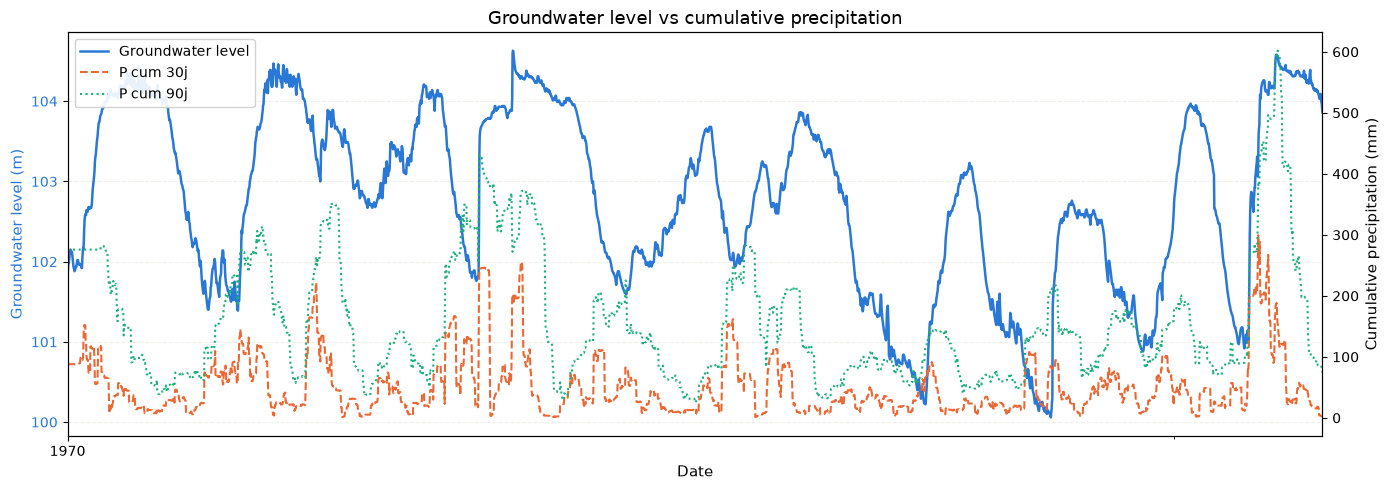

In [66]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Conversion explicite de l'index
df.index = pd.to_datetime(df.index)

fig, ax1 = plt.subplots(figsize=(14, 5))

# --- Bandes annuelles alternées ---
for i, year in enumerate(range(2017, 2027)):
    if i % 2 == 0:
        ax1.axvspan(
            pd.Timestamp(f"{year}-01-01"),
            pd.Timestamp(f"{year+1}-01-01"),
            color="#f5f5f3", alpha=0.6, zorder=0
        )

# --- Axe gauche : niveau nappe d'eau ---
color_nappe = "#2a78d6"
ax1.plot(df.index, df["niveau_nappe_eau"],
         color=color_nappe, linewidth=1.8, label="Groundwater level")
ax1.set_ylabel("Groundwater level (m)", color=color_nappe, fontsize=11)
ax1.tick_params(axis="y", labelcolor=color_nappe)

# --- Axe droit : précipitations cumulées ---
ax2 = ax1.twinx()
color_30 = "#eb6834"
color_90 = "#1baf7a"

ax2.plot(df.index, df["P_cum_30d"],
         color=color_30, linewidth=1.5, linestyle="--", label="P cum 30j")
ax2.plot(df.index, df["P_cum_90d"],
         color=color_90, linewidth=1.5, linestyle=":",  label="P cum 90j")
ax2.set_ylabel("Cumulative precipitation (mm)", fontsize=11)

# --- Limites X explicites ---
ax1.set_xlim(pd.Timestamp(min(df.index)), pd.Timestamp(max(df.index)))

# --- Format axe X ---
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))

# --- Mise en forme ---
ax1.set_xlabel("Date", fontsize=11)
ax1.set_title("Groundwater level vs cumulative precipitation", fontsize=13, fontweight="500")
ax1.grid(axis="x", color="#e1e0d9", linewidth=0.8)
ax1.grid(axis="y", color="#e1e0d9", linewidth=0.8, linestyle="--", alpha=0.5)

# --- Légende unifiée ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper left", framealpha=0.9, fontsize=10)

fig.autofmt_xdate(rotation=0, ha="center")
fig.tight_layout()
plt.show()

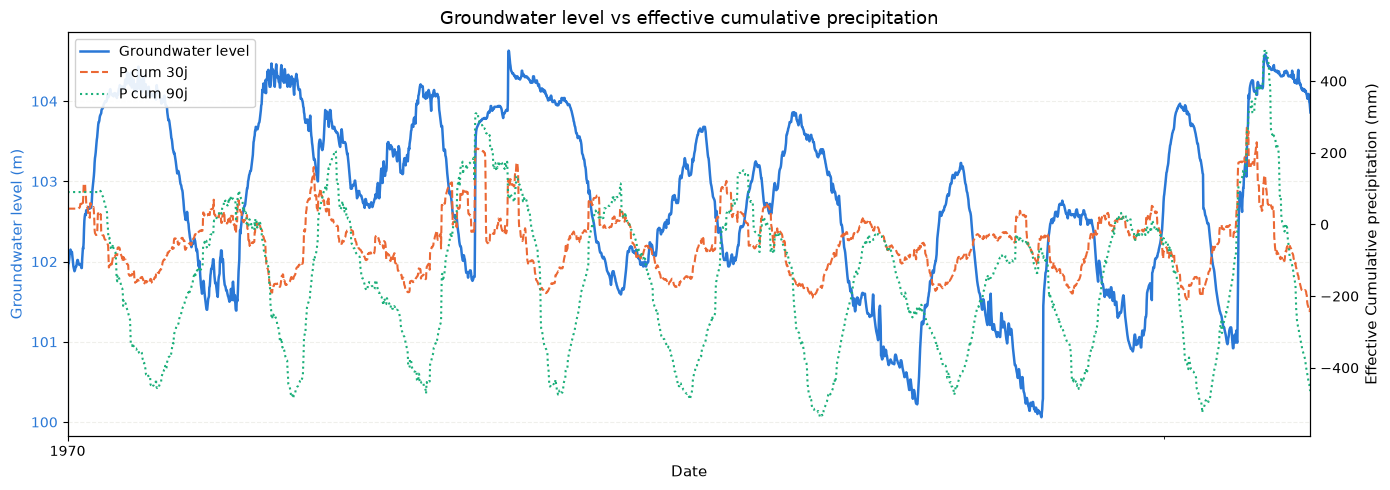

In [67]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Conversion explicite de l'index
df.index = pd.to_datetime(df.index)

fig, ax1 = plt.subplots(figsize=(14, 5))

# --- Bandes annuelles alternées ---
for i, year in enumerate(range(2017, 2027)):
    if i % 2 == 0:
        ax1.axvspan(
            pd.Timestamp(f"{year}-01-01"),
            pd.Timestamp(f"{year+1}-01-01"),
            color="#f5f5f3", alpha=0.6, zorder=0
        )

# --- Axe gauche : niveau nappe d'eau ---
color_nappe = "#2a78d6"
ax1.plot(df.index, df["niveau_nappe_eau"],
         color=color_nappe, linewidth=1.8, label="Groundwater level")
ax1.set_ylabel("Groundwater level (m)", color=color_nappe, fontsize=11)
ax1.tick_params(axis="y", labelcolor=color_nappe)

# --- Axe droit : précipitations cumulées ---
ax2 = ax1.twinx()
color_30 = "#eb6834"
color_90 = "#1baf7a"

ax2.plot(df.index, df["Peff_cum_30d"],
         color=color_30, linewidth=1.5, linestyle="--", label="P cum 30j")
ax2.plot(df.index, df["Peff_cum_90d"],
         color=color_90, linewidth=1.5, linestyle=":",  label="P cum 90j")
ax2.set_ylabel("Effective Cumulative precipitation (mm)", fontsize=11)

# --- Limites X explicites ---
ax1.set_xlim(pd.Timestamp(min(df.index)), pd.Timestamp(max(df.index)))

# --- Format axe X ---
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))

# --- Mise en forme ---
ax1.set_xlabel("Date", fontsize=11)
ax1.set_title("Groundwater level vs effective cumulative precipitation", fontsize=13, fontweight="500")
ax1.grid(axis="x", color="#e1e0d9", linewidth=0.8)
ax1.grid(axis="y", color="#e1e0d9", linewidth=0.8, linestyle="--", alpha=0.5)

# --- Légende unifiée ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper left", framealpha=0.9, fontsize=10)

fig.autofmt_xdate(rotation=0, ha="center")
fig.tight_layout()
plt.show()

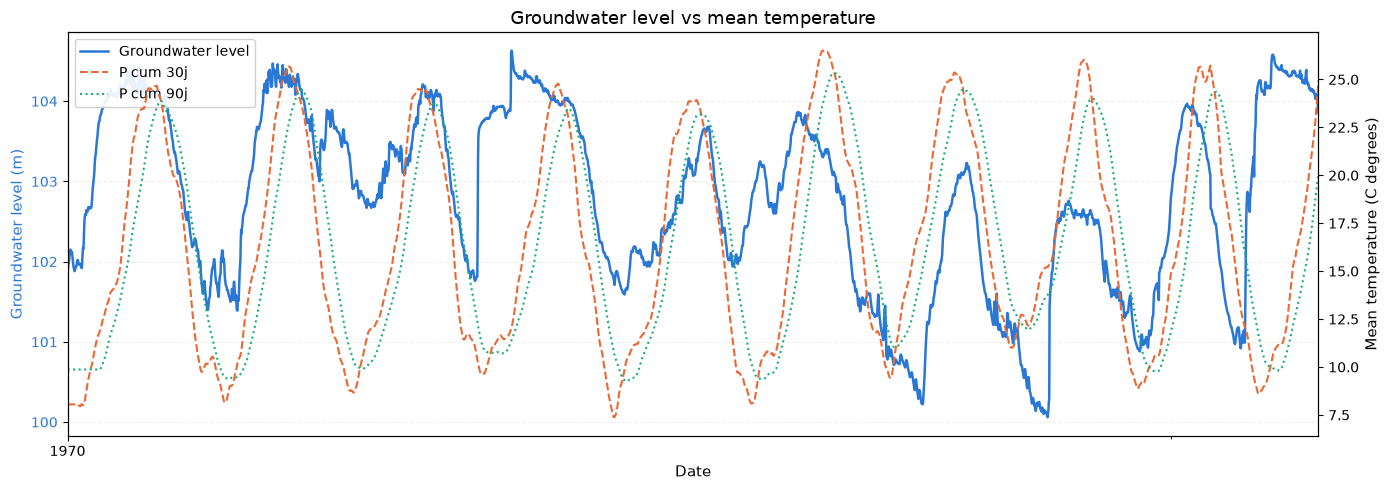

In [68]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Conversion explicite de l'index
df.index = pd.to_datetime(df.index)

fig, ax1 = plt.subplots(figsize=(14, 5))

# --- Bandes annuelles alternées ---
for i, year in enumerate(range(2017, 2027)):
    if i % 2 == 0:
        ax1.axvspan(
            pd.Timestamp(f"{year}-01-01"),
            pd.Timestamp(f"{year+1}-01-01"),
            color="#f5f5f3", alpha=0.6, zorder=0
        )

# --- Axe gauche : niveau nappe d'eau ---
color_nappe = "#2a78d6"
ax1.plot(df.index, df["niveau_nappe_eau"],
         color=color_nappe, linewidth=1.8, label="Groundwater level")
ax1.set_ylabel("Groundwater level (m)", color=color_nappe, fontsize=11)
ax1.tick_params(axis="y", labelcolor=color_nappe)

# --- Axe droit : précipitations cumulées ---
ax2 = ax1.twinx()
color_30 = "#eb6834"
color_90 = "#1baf7a"

ax2.plot(df.index, df["Temperature_mean_30d"],
         color=color_30, linewidth=1.5, linestyle="--", label="P cum 30j")
ax2.plot(df.index, df["Temperature_mean_90d"],
         color=color_90, linewidth=1.5, linestyle=":",  label="P cum 90j")
ax2.set_ylabel("Mean temperature (C degrees)", fontsize=11)

# --- Limites X explicites ---
ax1.set_xlim(pd.Timestamp(min(df.index)), pd.Timestamp(max(df.index)))

# --- Format axe X ---
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))

# --- Mise en forme ---
ax1.set_xlabel("Date", fontsize=11)
ax1.set_title("Groundwater level vs mean temperature", fontsize=13, fontweight="500")
ax1.grid(axis="x", color="#e1e0d9", linewidth=0.8)
ax1.grid(axis="y", color="#e1e0d9", linewidth=0.8, linestyle="--", alpha=0.5)

# --- Légende unifiée ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper left", framealpha=0.9, fontsize=10)

fig.autofmt_xdate(rotation=0, ha="center")
fig.tight_layout()
plt.show()